In [ ]:
import pandas as pd

file_path = "/content/Dataset for Data Analytics.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Sheets available:")
print(excel_file.sheet_names)

Sheets available:
['Sheet1']


In [ ]:
print("HELLO")

HELLO


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Dataset for Data Analytics.xlsx', 'sample_data']


In [ ]:
import pandas as pd

file_path = "/content/Dataset for Data Analytics.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Sheets available:")
print(excel_file.sheet_names)

Sheets available:
['Sheet1']


In [ ]:
df = pd.read_excel("/content/Dataset for Data Analytics.xlsx", sheet_name="Sheet1")

print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows and columns: (1200, 14)

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1200, 14)

Data types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate rows: 0


In [ ]:
import sqlite3

# Create an in-memory SQL database
conn = sqlite3.connect(":memory:")

# Load Excel data into SQL table
df.to_sql("orders", conn, index=False, if_exists="replace")

print("SQL table 'orders' created successfully!")

SQL table 'orders' created successfully!


In [ ]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23 00:00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15 00:00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23 00:00:00,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17 00:00:00,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12 00:00:00,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02 00:00:00,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,None,Email,268.56
9,ORD200009,2023-11-21 00:00:00,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


In [ ]:
query = """
SELECT
    COUNT(*) AS Total_Orders,
    SUM(Quantity) AS Total_Quantity_Sold,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Total_Orders,Total_Quantity_Sold,Total_Sales
0,1200,3535,1264761.96


In [ ]:
query = """
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Number_of_Orders,Total_Quantity,Total_Sales
0,Chair,178,562,195620.11
1,Printer,181,542,195612.61
2,Laptop,173,535,192126.56
3,Tablet,179,497,186568.95
4,Monitor,163,480,175651.41
5,Desk,170,508,167459.93
6,Phone,156,411,151722.39


In [ ]:
query = """
SELECT
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY OrderStatus
ORDER BY Number_of_Orders DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderStatus,Number_of_Orders,Total_Quantity,Total_Sales
0,Cancelled,250,759,276396.21
1,Returned,247,682,243277.70
2,Pending,237,724,256328.15
3,Shipped,235,680,246159.58
4,Delivered,231,690,242600.32


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY PaymentMethod
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,PaymentMethod,Number_of_Orders,Total_Quantity,Total_Sales
0,Credit Card,234,712,263847.63
1,Online,258,731,262442.94
2,Cash,246,753,259786.29
3,Gift Card,230,675,246323.92
4,Debit Card,232,664,232361.18


In [ ]:
query = """
SELECT
    ReferralSource,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ReferralSource
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,ReferralSource,Number_of_Orders,Total_Quantity,Total_Sales
0,Instagram,259,770,275285.45
1,Email,250,746,261808.55
2,Google,241,714,250441.48
3,Facebook,228,674,250410.90
4,Referral,222,631,226815.58


In [ ]:
query = """
SELECT
    COALESCE(CouponCode, 'No Coupon') AS Coupon_Code,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY CouponCode
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Coupon_Code,Number_of_Orders,Total_Quantity,Total_Sales
0,FREESHIP,313,914,335036.99
1,No Coupon,309,941,322401.41
2,SAVE10,286,844,304840.02
3,WINTER15,292,836,302483.54


In [ ]:
query = """
SELECT
    strftime('%Y', Date) AS Year,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%Y', Date)
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,Number_of_Orders,Total_Quantity,Total_Sales
0,2023,510,1524,552643.24
1,2024,459,1351,480235.87
2,2025,231,660,231882.85


In [ ]:
query = """
SELECT
    strftime('%Y-%m', Date) AS Month,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%Y-%m', Date)
ORDER BY Month;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Month,Number_of_Orders,Total_Quantity,Total_Sales
0,2023-01,47,146,56685.75
1,2023-02,37,102,40117.66
2,2023-03,43,126,48609.37
3,2023-04,31,84,27751.71
4,2023-05,49,148,63836.84
5,2023-06,45,146,49500.19
6,2023-07,44,119,42820.66
7,2023-08,51,174,54352.14
8,2023-09,29,86,29526.67
9,2023-10,47,150,52607.85


In [ ]:
query = """
SELECT
    COUNT(*) AS Total_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value,
    ROUND(AVG(Quantity), 2) AS Average_Quantity_Per_Order
FROM orders;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Total_Orders,Total_Sales,Average_Order_Value,Average_Quantity_Per_Order
0,1200,1264761.96,1053.97,2.95


In [ ]:
query = """
SELECT
    CustomerID,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY CustomerID
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,CustomerID,Number_of_Orders,Total_Quantity,Total_Sales
0,C38840,2,9,5723.23
1,C57276,1,5,3456.40
2,C67260,1,5,3390.80
3,C13877,1,5,3384.90
4,C18404,1,5,3370.20
5,C16775,1,5,3353.75
6,C65986,1,5,3352.40
7,C47778,1,5,3334.00
8,C59183,1,5,3322.55
9,C25276,1,5,3313.90


In [ ]:
query = """
SELECT
    ShippingAddress,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ShippingAddress
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,ShippingAddress,Number_of_Orders,Total_Quantity,Total_Sales
0,533 Main St,8,19,7753.73
1,558 Main St,4,13,7527.40
2,740 Main St,5,15,6761.84
3,747 Main St,5,19,6700.24
4,811 Main St,3,12,6668.36
5,160 Main St,4,14,6536.79
6,552 Main St,4,13,6521.03
7,619 Main St,3,14,6380.38
8,922 Main St,3,11,6367.75
9,165 Main St,2,10,6161.45


In [ ]:
query = """
SELECT
    Product,
    ROUND(AVG(UnitPrice), 2) AS Average_Unit_Price,
    ROUND(MIN(UnitPrice), 2) AS Minimum_Unit_Price,
    ROUND(MAX(UnitPrice), 2) AS Maximum_Unit_Price
FROM orders
GROUP BY Product
ORDER BY Average_Unit_Price DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Average_Unit_Price,Minimum_Unit_Price,Maximum_Unit_Price
0,Phone,375.22,11.39,695.10
1,Tablet,367.68,17.24,699.88
2,Monitor,358.66,14.69,696.71
3,Laptop,357.71,18.20,699.93
4,Chair,355.66,14.93,695.29
5,Printer,351.71,12.10,697.19
6,Desk,329.61,26.95,697.93


In [ ]:
query = """
SELECT
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY OrderStatus
ORDER BY Average_Order_Value DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderStatus,Number_of_Orders,Total_Sales,Average_Order_Value
0,Cancelled,250,276396.21,1105.58
1,Pending,237,256328.15,1081.55
2,Delivered,231,242600.32,1050.22
3,Shipped,235,246159.58,1047.49
4,Returned,247,243277.70,984.93


In [ ]:
query = """
SELECT
    strftime('%Y-%m', Date) AS Month,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%Y-%m', Date)
ORDER BY Month;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Month,Number_of_Orders,Total_Quantity,Total_Sales
0,2023-01,47,146,56685.75
1,2023-02,37,102,40117.66
2,2023-03,43,126,48609.37
3,2023-04,31,84,27751.71
4,2023-05,49,148,63836.84
5,2023-06,45,146,49500.19
6,2023-07,44,119,42820.66
7,2023-08,51,174,54352.14
8,2023-09,29,86,29526.67
9,2023-10,47,150,52607.85


In [ ]:
query = """
SELECT
    OrderID,
    Date,
    CustomerID,
    Product,
    Quantity,
    ROUND(UnitPrice, 2) AS UnitPrice,
    ROUND(TotalPrice, 2) AS TotalPrice,
    OrderStatus,
    PaymentMethod
FROM orders
ORDER BY TotalPrice DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,TotalPrice,OrderStatus,PaymentMethod
0,ORD200789,2023-08-17 00:00:00,C57276,Tablet,5,691.28,3456.40,Delivered,Online
1,ORD201122,2023-06-07 00:00:00,C38840,Monitor,5,678.19,3390.95,Returned,Online
2,ORD200632,2023-05-02 00:00:00,C67260,Laptop,5,678.16,3390.80,Delivered,Gift Card
3,ORD200469,2023-11-26 00:00:00,C13877,Chair,5,676.98,3384.90,Cancelled,Cash
4,ORD200328,2023-02-28 00:00:00,C18404,Tablet,5,674.04,3370.20,Cancelled,Online
5,ORD200107,2023-03-27 00:00:00,C16775,Printer,5,670.75,3353.75,Shipped,Gift Card
6,ORD200326,2024-07-01 00:00:00,C65986,Laptop,5,670.48,3352.40,Returned,Gift Card
7,ORD201065,2023-10-30 00:00:00,C47778,Printer,5,666.80,3334.00,Delivered,Debit Card
8,ORD201031,2023-02-28 00:00:00,C59183,Phone,5,664.51,3322.55,Pending,Debit Card
9,ORD200463,2023-05-26 00:00:00,C25276,Laptop,5,662.78,3313.90,Shipped,Debit Card


In [ ]:
query = """
SELECT
    CASE CAST(strftime('%w', Date) AS INTEGER)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END AS Day_of_Week,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%w', Date)
ORDER BY CAST(strftime('%w', Date) AS INTEGER);
"""

result = pd.read_sql_query(query, conn)
display(result)

,Day_of_Week,Number_of_Orders,Total_Quantity,Total_Sales
0,Sunday,186,545,199194.84
1,Monday,174,522,184009.38
2,Tuesday,165,478,180780.14
3,Wednesday,163,482,160519.31
4,Thursday,166,505,182066.56
5,Friday,174,519,190598.20
6,Saturday,172,484,167593.53


In [ ]:
query = """
SELECT
    PaymentMethod,
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY PaymentMethod, OrderStatus
ORDER BY PaymentMethod, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,PaymentMethod,OrderStatus,Number_of_Orders,Total_Sales
0,Cash,Pending,52,57258.11
1,Cash,Returned,57,56152.14
2,Cash,Cancelled,49,55900.71
3,Cash,Shipped,43,47617.64
4,Cash,Delivered,45,42857.69
5,Credit Card,Cancelled,54,64085.37
6,Credit Card,Pending,48,58543.12
7,Credit Card,Returned,49,53647.88
8,Credit Card,Delivered,43,46054.96
9,Credit Card,Shipped,40,41516.30


In [ ]:
query = """
SELECT
    ReferralSource,
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ReferralSource, Product
ORDER BY ReferralSource, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,ReferralSource,Product,Number_of_Orders,Total_Quantity,Total_Sales
0,Email,Chair,41,121,47821.77
1,Email,Tablet,40,123,45373.45
2,Email,Printer,41,127,44853.05
3,Email,Phone,34,96,36528.67
4,Email,Laptop,33,104,35655.01
5,Email,Monitor,32,101,34861.90
6,Email,Desk,29,74,16714.70
7,Facebook,Monitor,37,112,40718.95
8,Facebook,Chair,37,120,40385.07
9,Facebook,Printer,36,101,39558.03


In [ ]:
query = """
SELECT
    CASE
        WHEN CouponCode IS NULL THEN 'No Coupon'
        ELSE 'Coupon Used'
    END AS Coupon_Status,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY
    CASE
        WHEN CouponCode IS NULL THEN 'No Coupon'
        ELSE 'Coupon Used'
    END
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Coupon_Status,Number_of_Orders,Total_Quantity,Total_Sales,Average_Order_Value
0,Coupon Used,891,2594,942360.55,1057.64
1,No Coupon,309,941,322401.41,1043.37


In [ ]:
query = """
SELECT
    CustomerID,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY CustomerID
HAVING COUNT(*) > 1
ORDER BY Number_of_Orders DESC, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,CustomerID,Number_of_Orders,Total_Quantity,Total_Sales
0,C38840,2,9,5723.23
1,C97593,2,5,2855.22
2,C98474,2,6,2175.34
3,C70659,2,8,1853.96
4,C94569,2,3,1675.35
5,C46651,2,5,1360.89
6,C35852,2,7,1248.39
7,C14847,2,5,1097.81
8,C91155,2,6,704.82
9,C21191,2,3,647.77


In [ ]:
query = """
SELECT
    Quantity,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY Quantity
ORDER BY Quantity;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Quantity,Number_of_Orders,Total_Sales,Average_Order_Value
0,1,255,89728.29,351.88
1,2,240,165729.68,690.54
2,3,237,261276.18,1102.43
3,4,251,368090.96,1466.50
4,5,217,379936.85,1750.86


In [ ]:
query = """
SELECT
    Product,
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product, OrderStatus
ORDER BY Product, Number_of_Orders DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,OrderStatus,Number_of_Orders,Total_Quantity,Total_Sales
0,Chair,Cancelled,45,142,48660.98
1,Chair,Pending,41,145,48504.70
2,Chair,Delivered,33,105,31465.83
3,Chair,Shipped,31,99,40350.44
4,Chair,Returned,28,71,26638.16
5,Desk,Pending,38,124,41390.08
6,Desk,Cancelled,35,107,39587.69
7,Desk,Shipped,33,97,33424.89
8,Desk,Returned,32,86,28831.49
9,Desk,Delivered,32,94,24225.78


In [ ]:
query = """
SELECT
    strftime('%Y', Date) AS Year,
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%Y', Date), Product
ORDER BY Year, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Year,Product,Number_of_Orders,Total_Quantity,Total_Sales
0,2023,Printer,82,243,95513.73
1,2023,Chair,80,244,87585.58
2,2023,Tablet,77,225,86678.92
3,2023,Laptop,74,229,83231.66
4,2023,Monitor,71,205,75876.42
5,2023,Phone,60,178,62766.40
6,2023,Desk,66,200,60990.53
7,2024,Chair,70,237,84785.75
8,2024,Laptop,63,206,75611.41
9,2024,Monitor,63,177,68450.23


In [ ]:
query = """
SELECT
    strftime('%Y-%m', Date) AS Month,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY strftime('%Y-%m', Date)
ORDER BY Month;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Month,Number_of_Orders,Total_Sales,Average_Order_Value
0,2023-01,47,56685.75,1206.08
1,2023-02,37,40117.66,1084.26
2,2023-03,43,48609.37,1130.45
3,2023-04,31,27751.71,895.22
4,2023-05,49,63836.84,1302.79
5,2023-06,45,49500.19,1100.00
6,2023-07,44,42820.66,973.20
7,2023-08,51,54352.14,1065.73
8,2023-09,29,29526.67,1018.16
9,2023-10,47,52607.85,1119.32


In [ ]:
query = """
SELECT
    OrderStatus,
    COUNT(DISTINCT CustomerID) AS Unique_Customers,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY OrderStatus
ORDER BY Unique_Customers DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderStatus,Unique_Customers,Number_of_Orders,Total_Sales
0,Cancelled,250,250,276396.21
1,Returned,247,247,243277.70
2,Shipped,235,235,246159.58
3,Pending,235,237,256328.15
4,Delivered,231,231,242600.32


In [ ]:
query = """
SELECT
    CustomerID,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY CustomerID
ORDER BY Number_of_Orders DESC, Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,CustomerID,Number_of_Orders,Total_Quantity,Total_Sales
0,C38840,2,9,5723.23
1,C97593,2,5,2855.22
2,C98474,2,6,2175.34
3,C70659,2,8,1853.96
4,C94569,2,3,1675.35
5,C46651,2,5,1360.89
6,C35852,2,7,1248.39
7,C14847,2,5,1097.81
8,C91155,2,6,704.82
9,C21191,2,3,647.77


In [ ]:
query = """
SELECT
    Product,
    PaymentMethod,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product, PaymentMethod
ORDER BY Product, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,PaymentMethod,Number_of_Orders,Total_Quantity,Total_Sales
0,Chair,Online,47,155,54341.91
1,Chair,Gift Card,36,106,38064.35
2,Chair,Cash,34,104,35902.59
3,Chair,Credit Card,30,101,35405.05
4,Chair,Debit Card,31,96,31906.21
5,Desk,Gift Card,39,114,39498.39
6,Desk,Credit Card,37,110,37473.98
7,Desk,Cash,33,104,31644.97
8,Desk,Online,27,84,29526.11
9,Desk,Debit Card,34,96,29316.48


In [ ]:
query = """
SELECT
    ReferralSource,
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ReferralSource, OrderStatus
ORDER BY ReferralSource, Number_of_Orders DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,ReferralSource,OrderStatus,Number_of_Orders,Total_Quantity,Total_Sales
0,Email,Delivered,60,183,64553.52
1,Email,Cancelled,59,182,60266.49
2,Email,Returned,49,141,53755.05
3,Email,Pending,46,137,47639.34
4,Email,Shipped,36,103,35594.15
5,Facebook,Returned,56,161,64358.38
6,Facebook,Shipped,49,125,41040.22
7,Facebook,Delivered,42,137,52149.38
8,Facebook,Cancelled,42,135,50935.74
9,Facebook,Pending,39,116,41927.18


In [ ]:
query = """
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(AVG(Quantity), 2) AS Average_Quantity_Per_Order,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product
ORDER BY Average_Quantity_Per_Order DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Number_of_Orders,Total_Quantity,Average_Quantity_Per_Order,Total_Sales
0,Chair,178,562,3.16,195620.11
1,Laptop,173,535,3.09,192126.56
2,Printer,181,542,2.99,195612.61
3,Desk,170,508,2.99,167459.93
4,Monitor,163,480,2.94,175651.41
5,Tablet,179,497,2.78,186568.95
6,Phone,156,411,2.63,151722.39


In [ ]:
query = """
SELECT
    DATE(Date) AS Order_Date,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY DATE(Date)
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Order_Date,Number_of_Orders,Total_Quantity,Total_Sales
0,2023-08-20,8,32,9290.49
1,2023-02-16,5,21,8448.00
2,2024-04-07,7,19,8085.26
3,2023-11-24,3,12,7842.55
4,2024-06-19,4,14,7129.53
5,2025-03-15,6,16,6765.40
6,2023-02-28,2,10,6692.75
7,2023-03-27,4,14,6575.55
8,2023-06-11,4,14,6527.58
9,2025-06-24,5,16,6358.22


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY PaymentMethod
ORDER BY Average_Order_Value DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,PaymentMethod,Number_of_Orders,Total_Quantity,Total_Sales,Average_Order_Value
0,Credit Card,234,712,263847.63,1127.55
1,Gift Card,230,675,246323.92,1070.97
2,Cash,246,753,259786.29,1056.04
3,Online,258,731,262442.94,1017.22
4,Debit Card,232,664,232361.18,1001.56


In [ ]:
query = """
SELECT
    COALESCE(CouponCode, 'No Coupon') AS Coupon_Code,
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY CouponCode, OrderStatus
ORDER BY Coupon_Code, Number_of_Orders DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Coupon_Code,OrderStatus,Number_of_Orders,Total_Quantity,Total_Sales
0,FREESHIP,Cancelled,67,212,76366.09
1,FREESHIP,Pending,63,178,68984.90
2,FREESHIP,Shipped,61,177,61588.64
3,FREESHIP,Returned,61,169,62563.01
4,FREESHIP,Delivered,61,178,65534.35
5,No Coupon,Returned,76,212,75991.31
6,No Coupon,Shipped,64,180,65373.85
7,No Coupon,Pending,59,198,66496.36
8,No Coupon,Cancelled,58,188,61065.81
9,No Coupon,Delivered,52,163,53474.08


In [ ]:
query = """
SELECT
    ReferralSource,
    PaymentMethod,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ReferralSource, PaymentMethod
ORDER BY ReferralSource, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,ReferralSource,PaymentMethod,Number_of_Orders,Total_Quantity,Total_Sales
0,Email,Debit Card,59,176,63656.03
1,Email,Credit Card,53,161,56405.96
2,Email,Cash,48,147,51494.53
3,Email,Online,49,138,50405.51
4,Email,Gift Card,41,124,39846.52
5,Facebook,Online,52,149,58608.93
6,Facebook,Credit Card,44,144,56228.91
7,Facebook,Cash,52,156,49888.50
8,Facebook,Gift Card,41,116,47186.28
9,Facebook,Debit Card,39,109,38498.28


In [ ]:
query = """
SELECT
    Product,
    COALESCE(CouponCode, 'No Coupon') AS Coupon_Code,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product, CouponCode
ORDER BY Product, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Coupon_Code,Number_of_Orders,Total_Quantity,Total_Sales
0,Chair,No Coupon,48,163,58645.93
1,Chair,FREESHIP,44,128,52717.74
2,Chair,SAVE10,41,130,47948.88
3,Chair,WINTER15,45,141,36307.56
4,Desk,No Coupon,41,142,48222.17
5,Desk,FREESHIP,45,126,44480.34
6,Desk,WINTER15,49,137,42775.02
7,Desk,SAVE10,35,103,31982.40
8,Laptop,FREESHIP,45,140,53433.53
9,Laptop,No Coupon,46,149,51256.92


In [ ]:
query = """
SELECT
    strftime('%Y-%m', Date) AS Month,
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY strftime('%Y-%m', Date), Product
ORDER BY Month, Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Month,Product,Number_of_Orders,Total_Quantity,Total_Sales
0,2023-01,Chair,9,26,13555.72
1,2023-01,Monitor,9,28,12397.56
2,2023-01,Laptop,7,21,8987.38
3,2023-01,Phone,6,24,8347.76
4,2023-01,Printer,8,24,7091.55
...,...,...,...,...,...
204,2025-06,Laptop,8,23,8332.67
205,2025-06,Chair,7,26,7254.19
206,2025-06,Desk,7,19,7219.74
207,2025-06,Monitor,5,16,5646.25


In [ ]:
query = """
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(UnitPrice), 2) AS Average_Unit_Price,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Number_of_Orders,Total_Quantity,Total_Sales,Average_Unit_Price,Average_Order_Value
0,Chair,178,562,195620.11,355.66,1098.99
1,Printer,181,542,195612.61,351.71,1080.73
2,Laptop,173,535,192126.56,357.71,1110.56
3,Tablet,179,497,186568.95,367.68,1042.28
4,Monitor,163,480,175651.41,358.66,1077.62
5,Desk,170,508,167459.93,329.61,985.06
6,Phone,156,411,151722.39,375.22,972.58


In [ ]:
query = """
SELECT
    OrderID,
    Date,
    Product,
    Quantity,
    TotalPrice,
    OrderStatus
FROM orders
WHERE Date >= '2024-01-01'
  AND TotalPrice >= 2000
ORDER BY TotalPrice DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,OrderID,Date,Product,Quantity,TotalPrice,OrderStatus
0,ORD200326,2024-07-01 00:00:00,Laptop,5,3352.40,Returned
1,ORD200361,2024-06-29 00:00:00,Printer,5,3299.25,Delivered
2,ORD200367,2024-04-25 00:00:00,Laptop,5,3293.85,Pending
3,ORD200837,2025-06-14 00:00:00,Chair,5,3277.75,Delivered
4,ORD200527,2024-08-19 00:00:00,Chair,5,3267.35,Cancelled
...,...,...,...,...,...,...
96,ORD200304,2024-10-18 00:00:00,Monitor,5,2043.65,Delivered
97,ORD200458,2024-07-02 00:00:00,Monitor,4,2042.32,Returned
98,ORD200807,2024-11-10 00:00:00,Monitor,3,2028.63,Delivered
99,ORD200181,2024-08-31 00:00:00,Printer,5,2021.95,Shipped


In [ ]:
query = """
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY Product
HAVING COUNT(*) > 170
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Number_of_Orders,Total_Quantity,Total_Sales,Average_Order_Value
0,Chair,178,562,195620.11,1098.99
1,Printer,181,542,195612.61,1080.73
2,Laptop,173,535,192126.56,1110.56
3,Tablet,179,497,186568.95,1042.28


In [ ]:
query = """
SELECT
    Product,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(
        SUM(TotalPrice) * 100.0 / (SELECT SUM(TotalPrice) FROM orders),
        2
    ) AS Sales_Percentage
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
display(result)

,Product,Total_Sales,Sales_Percentage
0,Chair,195620.11,15.47
1,Printer,195612.61,15.47
2,Laptop,192126.56,15.19
3,Tablet,186568.95,14.75
4,Monitor,175651.41,13.89
5,Desk,167459.93,13.24
6,Phone,151722.39,12.00


In [ ]:
sql_queries = """
-- DecodeLabs Project 3: SQL Data Analysis
-- Dataset: Dataset for Data Analytics.xlsx

-- 1. Inspect the data
SELECT * FROM orders LIMIT 10;

-- 2. Count total orders
SELECT COUNT(*) AS Total_Orders
FROM orders;

-- 3. Filter orders using WHERE
SELECT
    OrderID,
    Date,
    Product,
    Quantity,
    TotalPrice,
    OrderStatus
FROM orders
WHERE Date >= '2024-01-01'
  AND TotalPrice >= 2000
ORDER BY TotalPrice DESC;

-- 4. Product-wise analysis
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;

-- 5. Order status analysis
SELECT
    OrderStatus,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY OrderStatus
ORDER BY Number_of_Orders DESC;

-- 6. Payment method analysis
SELECT
    PaymentMethod,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY PaymentMethod
ORDER BY Total_Sales DESC;

-- 7. Referral source analysis
SELECT
    ReferralSource,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY ReferralSource
ORDER BY Total_Sales DESC;

-- 8. Average Order Value
SELECT
    COUNT(*) AS Total_Orders,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value,
    ROUND(AVG(Quantity), 2) AS Average_Quantity_Per_Order
FROM orders;

-- 9. Coupon analysis
SELECT
    COALESCE(CouponCode, 'No Coupon') AS Coupon_Status,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales
FROM orders
GROUP BY Coupon_Status
ORDER BY Total_Sales DESC;

-- 10. Product analysis with AVG
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(UnitPrice), 2) AS Average_Unit_Price,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;

-- 11. HAVING example
SELECT
    Product,
    COUNT(*) AS Number_of_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(AVG(TotalPrice), 2) AS Average_Order_Value
FROM orders
GROUP BY Product
HAVING COUNT(*) > 170
ORDER BY Total_Sales DESC;

-- 12. Sales percentage contribution by product
SELECT
    Product,
    ROUND(SUM(TotalPrice), 2) AS Total_Sales,
    ROUND(
        SUM(TotalPrice) * 100.0 /
        (SELECT SUM(TotalPrice) FROM orders),
        2
    ) AS Sales_Percentage
FROM orders
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

with open("/content/DecodeLabs_Project_3_SQL_Queries.sql", "w") as f:
    f.write(sql_queries)

print("SQL file created successfully!")

SQL file created successfully!


In [ ]:
from google.colab import files

files.download("/content/DecodeLabs_Project_3_SQL_Queries.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
df.head()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_excel("/content/Dataset for Data Analytics.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset for Data Analytics.xlsx'

In [3]:
import pandas as pd

df = pd.read_excel("/content/Dataset for Data Analytics.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1200, 14)


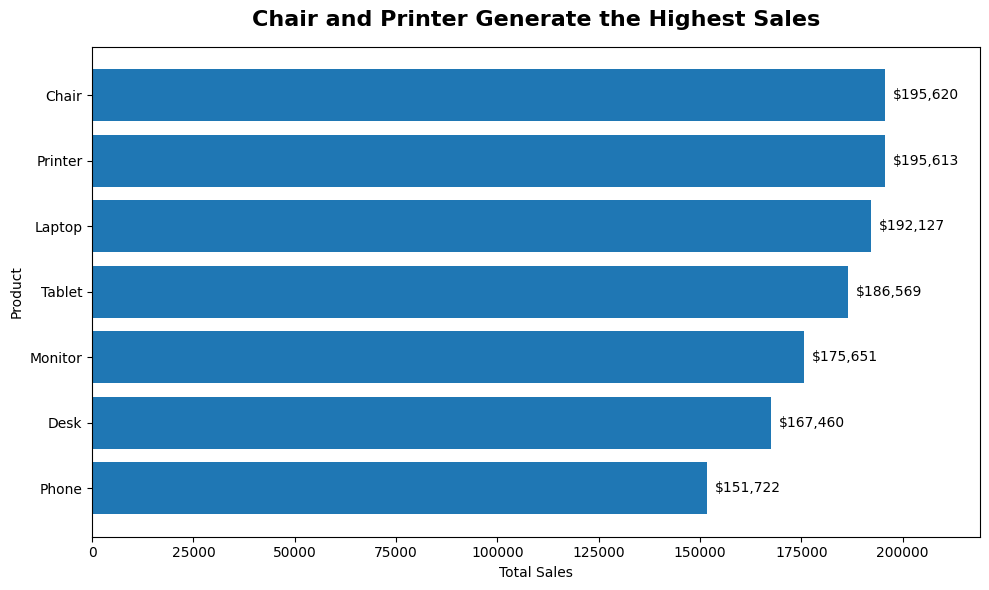

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt

# Calculate total sales by product
sales_by_product = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=True)
)

# Create chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    sales_by_product.index,
    sales_by_product.values
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2000,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Chair and Printer Generate the Highest Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.xlim(0, sales_by_product.max() * 1.12)

plt.tight_layout()
plt.show()
plt.savefig(
    "/content/Project_4_Charts/01_Sales_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

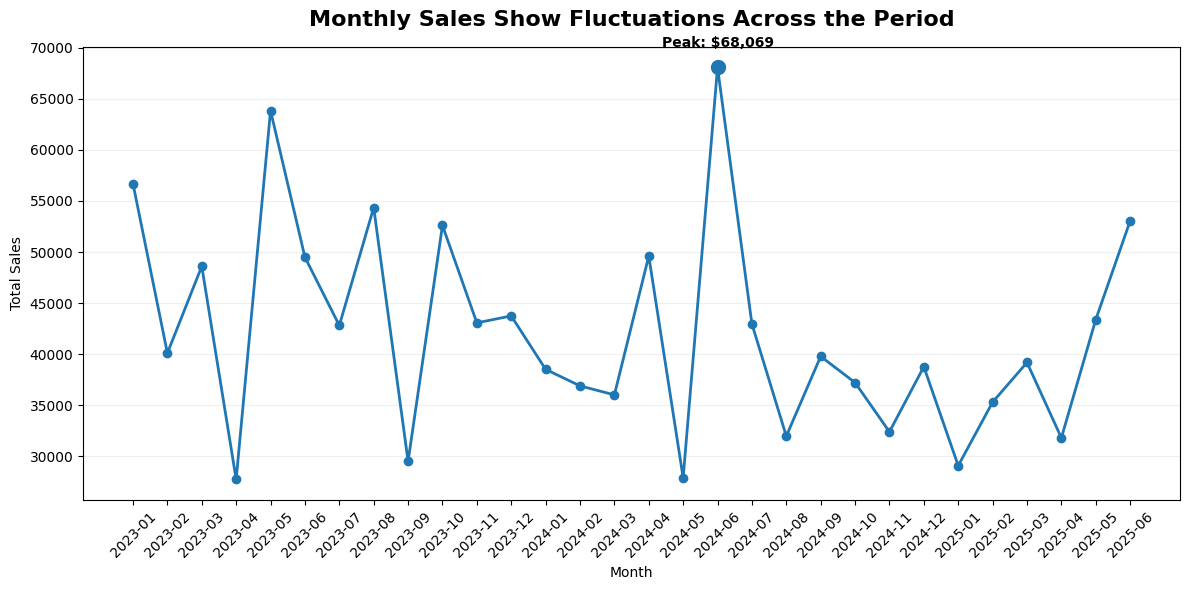

<Figure size 640x480 with 0 Axes>

In [11]:
# Calculate monthly sales
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["TotalPrice"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

# Highlight highest month
max_month = monthly_sales.idxmax()
max_value = monthly_sales.max()

plt.scatter(
    max_month,
    max_value,
    s=100,
    zorder=5
)

plt.annotate(
    f"Peak: ${max_value:,.0f}",
    xy=(max_month, max_value),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

plt.title(
    "Monthly Sales Show Fluctuations Across the Period",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()
plt.savefig(
    "/content/Project_4_Charts/02_Monthly_Sales_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

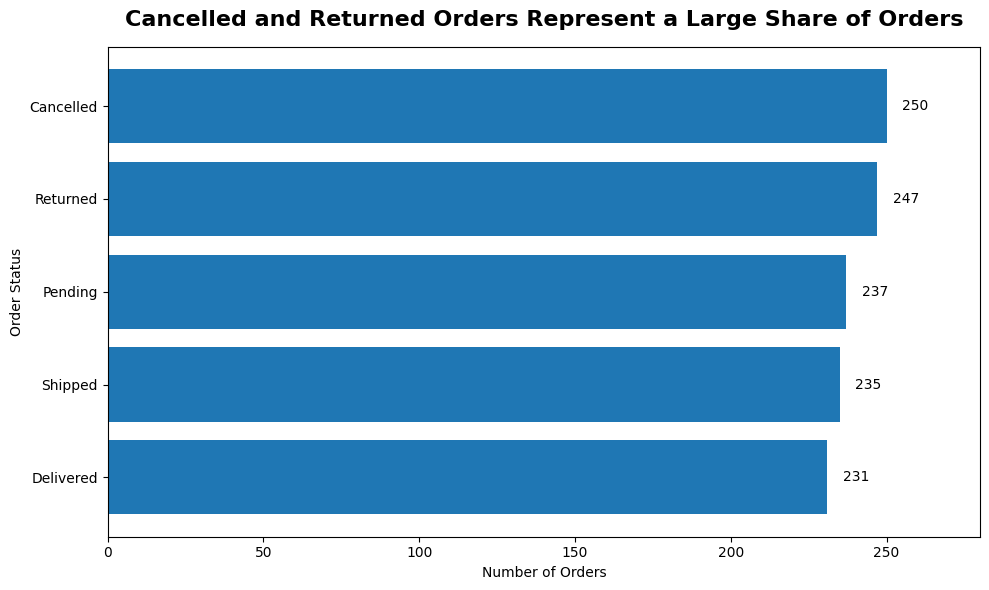

<Figure size 640x480 with 0 Axes>

In [12]:
# Count orders by status
status_counts = (
    df["OrderStatus"]
    .value_counts()
    .sort_values(ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    status_counts.index,
    status_counts.values
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.title(
    "Cancelled and Returned Orders Represent a Large Share of Orders",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.xlim(0, status_counts.max() * 1.12)

plt.tight_layout()
plt.show()
plt.savefig(
    "/content/Project_4_Charts/03_Order_Status.png",
    dpi=300,
    bbox_inches="tight"
)

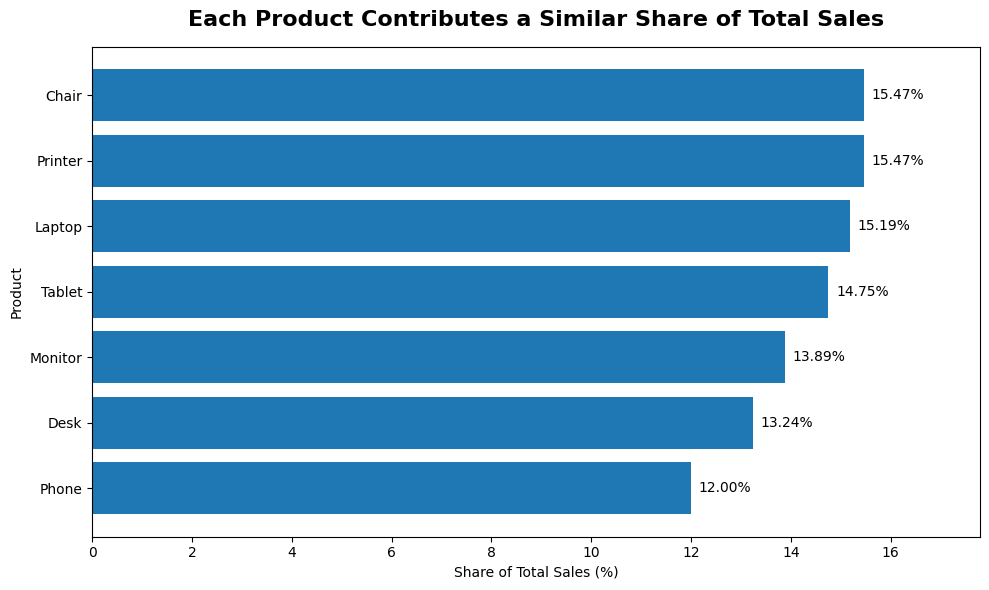

<Figure size 640x480 with 0 Axes>

In [13]:
# Calculate sales contribution by product
sales_contribution = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .div(df["TotalPrice"].sum())
    .mul(100)
    .sort_values(ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    sales_contribution.index,
    sales_contribution.values
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Each Product Contributes a Similar Share of Total Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Share of Total Sales (%)")
plt.ylabel("Product")

plt.xlim(0, sales_contribution.max() * 1.15)

plt.tight_layout()
plt.show()
plt.savefig(
    "/content/Project_4_Charts/04_Sales_Contribution.png",
    dpi=300,
    bbox_inches="tight"
)

In [8]:
import os

output_folder = "/content/Project_4_Charts"
os.makedirs(output_folder, exist_ok=True)

print("Chart folder created successfully!")
print(output_folder)

Chart folder created successfully!
/content/Project_4_Charts


In [14]:
import os

for file in sorted(os.listdir("/content/Project_4_Charts")):
    print("✓", file)

✓ 01_Sales_by_Product.png
✓ 02_Monthly_Sales_Trend.png
✓ 03_Order_Status.png
✓ 04_Sales_Contribution.png


In [15]:
import shutil

shutil.make_archive(
    "/content/Project_4_Charts",
    "zip",
    "/content/Project_4_Charts"
)

print("ZIP file created successfully!")
print("/content/Project_4_Charts.zip")

ZIP file created successfully!
/content/Project_4_Charts.zip


# DecodeLabs Project 4 – Data Visualization

**Track:** Data Analytics
**Project:** Data Visualization
**Dataset:** Dataset for Data Analytics.xlsx

## Objective

Create clear, purposeful visualizations to identify patterns, comparisons, trends, and key insights from the dataset.


## Dataset Overview

The dataset contains **1,200 order records** and **14 variables** covering customer orders from **January 2023 to June 2025**.

Key fields used for visualization include:

* **Date** – order date
* **Product** – product category
* **TotalPrice** – total order value
* **OrderStatus** – current status of each order

The visualizations were created using Python and Matplotlib in Google Colab.


## 1. Sales by Product

**Chart type:** Horizontal Bar Chart

**Business question:** Which products generate the highest total sales?

**Key insight:** Chair and Printer generate the highest total sales among the seven products, while Phone contributes the lowest total sales.

**Why this chart was selected:** A horizontal bar chart makes it easy to compare product categories and rank them from lowest to highest sales. It also keeps the product labels easy to read.


## 2. Monthly Sales Trend

**Chart type:** Line Chart

**Business question:** How do sales change over time?

**Key insight:** Monthly sales fluctuate throughout the period from January 2023 to June 2025, with a clear peak month highlighted on the chart.

**Why this chart was selected:** A line chart is appropriate for time-series data because it clearly shows changes, fluctuations, and peaks across consecutive months.


## 3. Order Status Distribution

**Chart type:** Horizontal Bar Chart

**Business question:** How are orders distributed across different order statuses?

**Key insight:** Cancelled and Returned orders represent a substantial share of the total orders, while the remaining orders are distributed across Pending, Shipped, and Delivered statuses.

**Why this chart was selected:** A horizontal bar chart allows direct comparison of the number of orders in each status and makes differences between categories easy to identify.


## 4. Sales Contribution by Product

**Chart type:** Horizontal Bar Chart

**Business question:** How much does each product contribute to total sales?

**Key insight:** The seven products contribute relatively similar shares of total sales, with no single product dominating the overall sales contribution.

**Why this chart was selected:** A horizontal bar chart makes percentage contributions easy to compare across all product categories while keeping the values directly visible.


## Project Summary

This project demonstrates the use of data visualization techniques to transform raw order data into clear and meaningful insights.

Four visualizations were created:

1. **Sales by Product** – compared total sales across products.
2. **Monthly Sales Trend** – examined sales fluctuations over time.
3. **Order Status Distribution** – compared orders across different statuses.
4. **Sales Contribution by Product** – examined each product's share of total sales.

The visualizations follow basic data storytelling principles by using appropriate chart types, clear titles, readable labels, and direct presentation of key insights.

### Tools Used

* Python
* Pandas
* Matplotlib
* Google Colab
* Excel dataset
